# Task B — ST-GCN : Prédiction de Congestion Urbaine
**Dataset** : METR-CA 2021 (California) — `liuxu77/largest`  
**Modèle** : Spatio-Temporal GCN (GCN + GRU)  
**Target** : prédire la congestion du jour J à partir de J-1, J-2, J-7  
**GPU** : T4 Kaggle (~15 min d'entraînement)

## 0. Installation des dépendances

In [2]:
# Installation rapide PyTorch Geometric sur Kaggle
import subprocess, sys

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch-geometric'
], check=True)

print('✅ PyTorch Geometric installé')

✅ PyTorch Geometric installé


## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings, os, time
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU : Tesla T4


## 2. Chargement des données

In [7]:
! ls /kaggle/input/datasets/liuxu77/largest

ca_his_raw_2017.h5  ca_his_raw_2019.h5	ca_his_raw_2021.h5  ca_rn_adj.npy
ca_his_raw_2018.h5  ca_his_raw_2020.h5	ca_meta.csv


In [8]:
# ── Chemins Kaggle ──────────────────────────────────────────────────────────
BASE  = '/kaggle/input/datasets/liuxu77/largest'
H5    = os.path.join(BASE, 'ca_his_raw_2021.h5')
META  = os.path.join(BASE, 'ca_meta.csv')
ADJ   = os.path.join(BASE, 'ca_rn_adj.npy')

# ── Explorer la structure HDF5 ──────────────────────────────────────────────
def explore_h5(f, prefix=''):
    for key in f.keys():
        item = f[key]
        path = f'{prefix}/{key}'
        if hasattr(item, 'shape'):
            print(f'  DATASET {path} → shape={item.shape}, dtype={item.dtype}')
        else:
            print(f'  GROUP   {path}')
            explore_h5(item, path)

with h5py.File(H5, 'r') as f:
    print('Structure HDF5 :')
    explore_h5(f)

Structure HDF5 :
  GROUP   /t
  DATASET /t/axis0 → shape=(8600,), dtype=|S9
  DATASET /t/axis1 → shape=(105120,), dtype=int64
  DATASET /t/block0_items → shape=(8600,), dtype=|S9
  DATASET /t/block0_values → shape=(105120, 8600), dtype=float64


## 3. Calcul de la congestion journalière

In [10]:
import h5py

H5 = '/kaggle/input/datasets/liuxu77/largest/ca_his_raw_2021.h5'

with h5py.File(H5, 'r') as f:
    def explore(obj, prefix=''):
        for k in obj.keys():
            item = obj[k]
            full = f'{prefix}/{k}'
            if isinstance(item, h5py.Dataset):
                print(f'DATASET {full} shape={item.shape} dtype={item.dtype}')
            else:
                print(f'GROUP   {full}')
                explore(item, full)
    explore(f)

GROUP   /t
DATASET /t/axis0 shape=(8600,) dtype=|S9
DATASET /t/axis1 shape=(105120,) dtype=int64
DATASET /t/block0_items shape=(8600,) dtype=|S9
DATASET /t/block0_values shape=(105120, 8600) dtype=float64


In [15]:
import h5py, numpy as np, os

H5         = '/kaggle/input/datasets/liuxu77/largest/ca_his_raw_2021.h5'
OUT_DIR    = '/kaggle/working/congestion_monthly'
os.makedirs(OUT_DIR, exist_ok=True)

N_SENSORS  = 8600
STEPS_DAY  = 288
FREE_SPEED = 65.0

# Jours par mois 2021 (année non bissextile)
jours_mois = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
noms_mois  = ['jan','fev','mar','avr','mai','jun',
              'jul','aou','sep','oct','nov','dec']

# On traite seulement les 3 premiers mois pour le GNN
MOIS_A_TRAITER = [0, 1, 2]   # janvier, février, mars

with h5py.File(H5, 'r') as f:
    step_offset = 0

    for m in range(12):
        n_days  = jours_mois[m]
        n_steps = n_days * STEPS_DAY

        if m not in MOIS_A_TRAITER:
            step_offset += n_steps
            continue

        print(f'\n📅 Mois {noms_mois[m]} ({n_days} jours, steps {step_offset}→{step_offset+n_steps})...')

        # ── Lecture chunk mensuel ────────────────────────────────────────────
        chunk = f['/t/block0_values'][step_offset:step_offset+n_steps, :].astype(np.float32)
        print(f'   Brut : min={np.nanmin(chunk):.1f}, max={np.nanmax(chunk):.1f}')

        # ── Nettoyage : garder uniquement [1, 120] mph ───────────────────────
        chunk[chunk <= 0]   = np.nan
        chunk[chunk > 120]  = np.nan   # 120 mph = seuil large

        # ── Remplir NaN par médiane du capteur ───────────────────────────────
        medians = np.nanmedian(chunk, axis=0)   # (8600,)
        # Si médiane est NaN (capteur mort) → mettre FREE_SPEED
        medians = np.where(np.isnan(medians), FREE_SPEED, medians)
        nan_idx = np.where(np.isnan(chunk))
        chunk[nan_idx] = medians[nan_idx[1]]

        print(f'   Propre : min={chunk.min():.1f}, max={chunk.max():.1f}, mean={chunk.mean():.1f} mph')
        print(f'   NaN restants : {np.isnan(chunk).sum()}')

        # ── Reshape → (n_days, 288, 8600) → mean → (n_days, 8600) ──────────
        speeds_3d   = chunk.reshape(n_days, STEPS_DAY, N_SENSORS)
        speed_daily = speeds_3d.mean(axis=1)   # (n_days, 8600)

        # ── Congestion [0,1] ─────────────────────────────────────────────────
        congestion_m = 1.0 - np.clip(speed_daily / FREE_SPEED, 0.0, 1.0)

        print(f'   Congestion : min={congestion_m.min():.3f}, max={congestion_m.max():.3f}, mean={congestion_m.mean():.3f}')

        # ── Sauvegarder ──────────────────────────────────────────────────────
        out_path = os.path.join(OUT_DIR, f'congestion_{noms_mois[m]}.npy')
        np.save(out_path, congestion_m)
        print(f'   ✅ Sauvegardé : {out_path}  shape={congestion_m.shape}')

        step_offset += n_steps

print('\n🎉 Terminé !')
print('Fichiers générés :')
for f_name in os.listdir(OUT_DIR):
    path = os.path.join(OUT_DIR, f_name)
    arr  = np.load(path)
    print(f'  {f_name} → shape={arr.shape}')


📅 Mois jan (31 jours, steps 0→8928)...
   Brut : min=0.0, max=999.0
   Propre : min=1.0, max=120.0, mean=61.4 mph
   NaN restants : 0
   Congestion : min=0.000, max=0.985, mean=0.144
   ✅ Sauvegardé : /kaggle/working/congestion_monthly/congestion_jan.npy  shape=(31, 8600)

📅 Mois fev (28 jours, steps 8928→16992)...
   Brut : min=0.0, max=999.0
   Propre : min=1.0, max=120.0, mean=62.1 mph
   NaN restants : 0
   Congestion : min=0.000, max=0.979, mean=0.143
   ✅ Sauvegardé : /kaggle/working/congestion_monthly/congestion_fev.npy  shape=(28, 8600)

📅 Mois mar (31 jours, steps 16992→25920)...
   Brut : min=0.0, max=999.0
   Propre : min=1.0, max=120.0, mean=63.3 mph
   NaN restants : 0
   Congestion : min=0.000, max=0.978, mean=0.135
   ✅ Sauvegardé : /kaggle/working/congestion_monthly/congestion_mar.npy  shape=(31, 8600)

🎉 Terminé !
Fichiers générés :
  congestion_fev.npy → shape=(28, 8600)
  congestion_mar.npy → shape=(31, 8600)
  congestion_jan.npy → shape=(31, 8600)


In [18]:
# ── Concat 3 mois → (90, 8600) ──────────────────────────────────────────────
OUT_DIR = '/kaggle/working/congestion_monthly'

congestion = np.concatenate([
    np.load(f'{OUT_DIR}/congestion_jan.npy'),
    np.load(f'{OUT_DIR}/congestion_fev.npy'),
    np.load(f'{OUT_DIR}/congestion_mar.npy'),
], axis=0)   # (90, 8600)

N_DAYS_USE = congestion.shape[0]  # 90
N_SENSORS  = congestion.shape[1]  # 8600
STEPS_DAY  = 288
FREE_SPEED = 65.0

print(f'✅ congestion shape : {congestion.shape}')
print(f'   min={congestion.min():.3f}, max={congestion.max():.3f}, mean={congestion.mean():.3f}')

# ── Features statiques depuis ca_meta.csv ────────────────────────────────────
META = '/kaggle/input/datasets/liuxu77/largest/ca_meta.csv'
meta = pd.read_csv(META).iloc[:N_SENSORS].copy()

for col in ['type', 'direction']:
    if col in meta.columns:
        from sklearn.preprocessing import LabelEncoder
        meta[col] = LabelEncoder().fit_transform(meta[col].astype(str))

for col in ['lat', 'lng', 'lanes']:
    if col in meta.columns:
        meta[col] = (meta[col] - meta[col].mean()) / (meta[col].std() + 1e-8)

feat_cols   = [c for c in ['lat','lng','lanes','type','direction'] if c in meta.columns]
node_static = meta[feat_cols].values.astype(np.float32)  # (8600, F_static)

print(f'✅ node_static shape : {node_static.shape}')
print(f'   Colonnes : {feat_cols}')

# ── Structure graphe depuis ca_rn_adj.npy ────────────────────────────────────
ADJ = '/kaggle/input/datasets/liuxu77/largest/ca_rn_adj.npy'
adj = np.load(ADJ)
rows, cols  = np.where(adj > 0)
edge_index  = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
edge_weight = torch.tensor(adj[rows, cols],         dtype=torch.float32)

print(f'✅ edge_index  shape : {edge_index.shape}')
print(f'   edge_weight shape : {edge_weight.shape}')

✅ congestion shape : (90, 8600)
   min=0.000, max=0.985, mean=0.141
✅ node_static shape : (8600, 0)
   Colonnes : []
✅ edge_index  shape : torch.Size([2, 209963])
   edge_weight shape : torch.Size([209963])


## 4. Features des nœuds (ca_meta.csv)

In [19]:
meta = pd.read_csv(META)
print(f'Meta shape : {meta.shape}')
print(meta.head(3))
print(meta.dtypes)

# ── Garder uniquement les 8600 premiers capteurs ─────────────────────────────
meta = meta.iloc[:N_SENSORS].copy()

# ── Encoder les colonnes catégorielles ───────────────────────────────────────
for col in ['type', 'direction']:
    if col in meta.columns:
        le = LabelEncoder()
        meta[col] = le.fit_transform(meta[col].astype(str))

# ── Normaliser lat, lng, lanes ────────────────────────────────────────────────
for col in ['lat', 'lng', 'lanes']:
    if col in meta.columns:
        meta[col] = (meta[col] - meta[col].mean()) / (meta[col].std() + 1e-8)

# ── Features statiques : lat, lng, lanes, type, direction ────────────────────
feat_cols = [c for c in ['lat', 'lng', 'lanes', 'type', 'direction'] if c in meta.columns]
node_static = meta[feat_cols].values.astype(np.float32)   # (8600, F_static)
print(f'\nFeatures statiques shape : {node_static.shape}')
print(f'Colonnes : {feat_cols}')

Meta shape : (8600, 10)
       ID        Lat         Lng  District      County   Fwy  Lanes      Type  \
0  317802  38.389811 -121.479587         3  Sacramento  I5-N      2  Mainline   
1  312134  38.412564 -121.484319         3  Sacramento  I5-N      2  Mainline   
2  312133  38.428630 -121.487657         3  Sacramento  I5-N      3  Mainline   

  Direction  ID2  
0         N    0  
1         N    1  
2         N    2  
ID             int64
Lat          float64
Lng          float64
District       int64
County        object
Fwy           object
Lanes          int64
Type          object
Direction     object
ID2            int64
dtype: object

Features statiques shape : (8600, 0)
Colonnes : []


## 5. Structure du graphe (ca_rn_adj.npy)

In [20]:
adj = np.load(ADJ)   # (8600, 8600)
print(f'Adjacency shape : {adj.shape}')
print(f'Non-zéro : {(adj > 0).sum()} arcs')

# ── Convertir en edge_index (format COO pour PyG) ────────────────────────────
rows, cols = np.where(adj > 0)
edge_index = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)   # (2, E)
edge_weight = torch.tensor(adj[rows, cols], dtype=torch.float32)       # (E,)

print(f'edge_index shape : {edge_index.shape}')
print(f'edge_weight min={edge_weight.min():.4f}, max={edge_weight.max():.4f}')

Adjacency shape : (8600, 8600)
Non-zéro : 209963 arcs
edge_index shape : torch.Size([2, 209963])
edge_weight min=0.0100, max=1.0000


## 6. Construction des séquences temporelles

In [21]:
# ── Paramètres séquence ───────────────────────────────────────────────────────
LOOKBACK = [1, 2, 7]   # on utilise J-1, J-2, J-7
MAX_LAG  = max(LOOKBACK)   # 7

# ── Jour de la semaine (0=lundi...6=dimanche) ────────────────────────────────
# Janvier 2021 commence un vendredi (4)
import datetime
start_date = datetime.date(2021, 1, 1)
day_of_week = np.array([
    (start_date + datetime.timedelta(days=i)).weekday()
    for i in range(N_DAYS_USE)
], dtype=np.float32) / 6.0   # normaliser [0,1]

# ── Construction X (inputs) et Y (targets) ───────────────────────────────────
X_list, Y_list = [], []

for day in range(MAX_LAG, N_DAYS_USE):
    # Congestion historique : J-1, J-2, J-7 → shape (3, 8600)
    hist = np.stack([congestion[day - lag] for lag in LOOKBACK], axis=0)  # (3, 8600)
    
    # Jour de la semaine (scalaire broadcast sur 8600 capteurs)
    dow = np.full((1, N_SENSORS), day_of_week[day], dtype=np.float32)     # (1, 8600)
    
    # Features statiques broadcast : (F_static, 8600)
    static_T = node_static.T   # (F_static, 8600)
    
    # Concat toutes les features → (3 + 1 + F_static, 8600)
    x_day = np.vstack([hist, dow, static_T])   # (3+1+F_static, 8600)
    
    X_list.append(x_day.T.astype(np.float32))   # (8600, F_total)
    Y_list.append(congestion[day].astype(np.float32))   # (8600,)

X = np.stack(X_list, axis=0)   # (N_samples, 8600, F_total)
Y = np.stack(Y_list, axis=0)   # (N_samples, 8600)

N_SAMPLES  = X.shape[0]   # 90 - 7 = 83
F_TOTAL    = X.shape[2]

print(f'X shape : {X.shape}  →  (jours, capteurs, features)')
print(f'Y shape : {Y.shape}  →  (jours, capteurs)')
print(f'Features total par nœud : {F_TOTAL}')

X shape : (83, 8600, 4)  →  (jours, capteurs, features)
Y shape : (83, 8600)  →  (jours, capteurs)
Features total par nœud : 4


## 7. Split Train / Val / Test (temporel)

In [22]:
# Split temporel : 70% train / 15% val / 15% test
n_train = int(N_SAMPLES * 0.70)
n_val   = int(N_SAMPLES * 0.15)
n_test  = N_SAMPLES - n_train - n_val

X_train, Y_train = X[:n_train],            Y[:n_train]
X_val,   Y_val   = X[n_train:n_train+n_val], Y[n_train:n_train+n_val]
X_test,  Y_test  = X[n_train+n_val:],       Y[n_train+n_val:]

print(f'Train : {n_train} jours  |  Val : {n_val} jours  |  Test : {n_test} jours')

# ── Convertir en tenseurs ────────────────────────────────────────────────────
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
Y_val_t   = torch.tensor(Y_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32)

edge_index = edge_index.to(DEVICE)
edge_weight = edge_weight.to(DEVICE)
print('✅ Tenseurs prêts')

Train : 58 jours  |  Val : 12 jours  |  Test : 13 jours
✅ Tenseurs prêts


## 8. Architecture ST-GCN (GCN + GRU)

In [23]:
class STGCN(nn.Module):
    """
    Spatio-Temporal GCN :
      - GCN  : capture les dépendances spatiales (voisins)
      - GRU  : capture l'évolution temporelle (J-1, J-2, J-7)
      - MLP  : prédit la congestion du jour J
    """
    def __init__(self, in_features, gcn_hidden=64, gru_hidden=64, out=1):
        super(STGCN, self).__init__()

        # ── Couches GCN spatiales ────────────────────────────────────────────
        self.gcn1 = GCNConv(in_features, gcn_hidden)
        self.gcn2 = GCNConv(gcn_hidden,  gcn_hidden)

        # ── Couche GRU temporelle ────────────────────────────────────────────
        # input_size = gcn_hidden, on traite chaque jour comme un pas de temps
        self.gru = nn.GRU(input_size=gcn_hidden,
                          hidden_size=gru_hidden,
                          num_layers=1,
                          batch_first=True)

        # ── Tête de prédiction ───────────────────────────────────────────────
        self.fc1 = nn.Linear(gru_hidden, 32)
        self.fc2 = nn.Linear(32, out)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x_seq, edge_index, edge_weight):
        """
        x_seq : (T, N, F)  T=séquence temporelle, N=capteurs, F=features
        """
        T, N, F = x_seq.shape
        gcn_out = []

        # ── Appliquer GCN sur chaque pas de temps ────────────────────────────
        for t in range(T):
            h = self.gcn1(x_seq[t], edge_index, edge_weight)   # (N, gcn_hidden)
            h = F.relu(h)
            h = self.dropout(h)
            h = self.gcn2(h, edge_index, edge_weight)           # (N, gcn_hidden)
            h = F.relu(h)
            gcn_out.append(h)   # (N, gcn_hidden)

        # ── Stack → (N, T, gcn_hidden) pour GRU ─────────────────────────────
        gcn_stack = torch.stack(gcn_out, dim=1)   # (N, T, gcn_hidden)

        # ── GRU : (N, T, gcn_hidden) → (N, gru_hidden) ──────────────────────
        _, h_n = self.gru(gcn_stack)   # h_n : (1, N, gru_hidden)
        h_n = h_n.squeeze(0)           # (N, gru_hidden)

        # ── MLP final ────────────────────────────────────────────────────────
        out = F.relu(self.fc1(h_n))    # (N, 32)
        out = torch.sigmoid(self.fc2(out)).squeeze(-1)   # (N,) → [0,1]
        return out


# ── Instanciation ────────────────────────────────────────────────────────────
model = STGCN(in_features=F_TOTAL, gcn_hidden=64, gru_hidden=64).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Modèle ST-GCN initialisé')
print(f'   Paramètres entraînables : {total_params:,}')
print(model)

✅ Modèle ST-GCN initialisé
   Paramètres entraînables : 31,553
STGCN(
  (gcn1): GCNConv(4, 64)
  (gcn2): GCNConv(64, 64)
  (gru): GRU(64, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


## 9. Entraînement

In [27]:
import torch.nn.functional as func

class STGCN(nn.Module):
    def __init__(self, in_features, gcn_hidden=64, gru_hidden=64, out=1):
        super(STGCN, self).__init__()
        self.gcn1    = GCNConv(in_features, gcn_hidden)
        self.gcn2    = GCNConv(gcn_hidden,  gcn_hidden)
        self.gru     = nn.GRU(input_size=gcn_hidden,
                              hidden_size=gru_hidden,
                              num_layers=1,
                              batch_first=True)
        self.fc1     = nn.Linear(gru_hidden, 32)
        self.fc2     = nn.Linear(32, out)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x_seq, edge_index, edge_weight):
        T, N, F_dim = x_seq.shape   # ← F_dim au lieu de F
        gcn_out = []

        for t in range(T):
            h = self.gcn1(x_seq[t], edge_index, edge_weight)
            h = func.relu(h)          # ← func au lieu de F
            h = self.dropout(h)
            h = self.gcn2(h, edge_index, edge_weight)
            h = func.relu(h)          # ← func au lieu de F
            gcn_out.append(h)

        gcn_stack = torch.stack(gcn_out, dim=1)   # (N, T, gcn_hidden)
        _, h_n    = self.gru(gcn_stack)
        h_n       = h_n.squeeze(0)                # (N, gru_hidden)

        out = func.relu(self.fc1(h_n))            # ← func au lieu de F
        out = torch.sigmoid(self.fc2(out)).squeeze(-1)
        return out

# Réinstancier le modèle
model = STGCN(in_features=F_TOTAL, gcn_hidden=64, gru_hidden=64).to(DEVICE)
print(f'✅ Modèle réinstancié — {sum(p.numel() for p in model.parameters()):,} paramètres')

✅ Modèle réinstancié — 31,553 paramètres


In [28]:
# ── Hyperparamètres ───────────────────────────────────────────────────────────
EPOCHS       = 100
LR           = 1e-3
PATIENCE     = 15      # early stopping
SEQ_LEN      = 1       # on traite 1 jour à la fois (x contient déjà J-1,J-2,J-7)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.MSELoss()

# ── Historique ────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f'🚀 Début entraînement — {EPOCHS} epochs max, early stopping patience={PATIENCE}')
print(f'   Train={n_train} jours | Val={n_val} jours | Test={n_test} jours')
print('-' * 60)

t0 = time.time()

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for i in range(n_train):
        x = X_train_t[i].unsqueeze(0).to(DEVICE)   # (1, N, F)
        y = Y_train_t[i].to(DEVICE)                 # (N,)

        optimizer.zero_grad()
        pred = model(x, edge_index, edge_weight)    # (N,)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= n_train

    # ── VALIDATION ───────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_preds, val_true = [], []

    with torch.no_grad():
        for i in range(n_val):
            x = X_val_t[i].unsqueeze(0).to(DEVICE)
            y = Y_val_t[i].to(DEVICE)
            pred = model(x, edge_index, edge_weight)
            val_loss += criterion(pred, y).item()
            val_preds.append(pred.cpu().numpy())
            val_true.append(y.cpu().numpy())

    val_loss /= n_val
    val_preds_flat = np.concatenate(val_preds)
    val_true_flat  = np.concatenate(val_true)
    val_mae = mean_absolute_error(val_true_flat, val_preds_flat)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    scheduler.step(val_loss)

    # ── Early stopping ────────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        saved = '✅ saved'
    else:
        patience_counter += 1
        saved = ''

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train Loss={train_loss:.4f} | '
              f'Val Loss={val_loss:.4f} | '
              f'Val MAE={val_mae:.4f} | '
              f'{elapsed:.0f}s {saved}')

    if patience_counter >= PATIENCE:
        print(f'\n⏹ Early stopping à l\'epoch {epoch} (patience={PATIENCE})')
        break

print(f'\n✅ Entraînement terminé en {time.time()-t0:.0f}s')
print(f'   Meilleur Val Loss : {best_val_loss:.4f}')

# ── Recharger le meilleur modèle ──────────────────────────────────────────────
model.load_state_dict(best_model_state)
torch.save(best_model_state, 'stgcn_best.pt')
print('   Modèle sauvegardé : stgcn_best.pt')

🚀 Début entraînement — 100 epochs max, early stopping patience=15
   Train=58 jours | Val=12 jours | Test=13 jours
------------------------------------------------------------
Epoch   1/100 | Train Loss=0.0737 | Val Loss=0.0318 | Val MAE=0.1416 | 2s ✅ saved
Epoch   5/100 | Train Loss=0.0138 | Val Loss=0.0133 | Val MAE=0.0879 | 5s ✅ saved
Epoch  10/100 | Train Loss=0.0135 | Val Loss=0.0131 | Val MAE=0.0859 | 9s ✅ saved
Epoch  15/100 | Train Loss=0.0134 | Val Loss=0.0131 | Val MAE=0.0851 | 13s ✅ saved
Epoch  20/100 | Train Loss=0.0134 | Val Loss=0.0130 | Val MAE=0.0846 | 16s ✅ saved
Epoch  25/100 | Train Loss=0.0133 | Val Loss=0.0129 | Val MAE=0.0842 | 20s ✅ saved
Epoch  30/100 | Train Loss=0.0133 | Val Loss=0.0129 | Val MAE=0.0839 | 24s ✅ saved
Epoch  35/100 | Train Loss=0.0133 | Val Loss=0.0129 | Val MAE=0.0835 | 28s ✅ saved
Epoch  40/100 | Train Loss=0.0132 | Val Loss=0.0129 | Val MAE=0.0834 | 32s ✅ saved
Epoch  45/100 | Train Loss=0.0132 | Val Loss=0.0129 | Val MAE=0.0830 | 35s 
Epoc

## 10. Courbes d'apprentissage

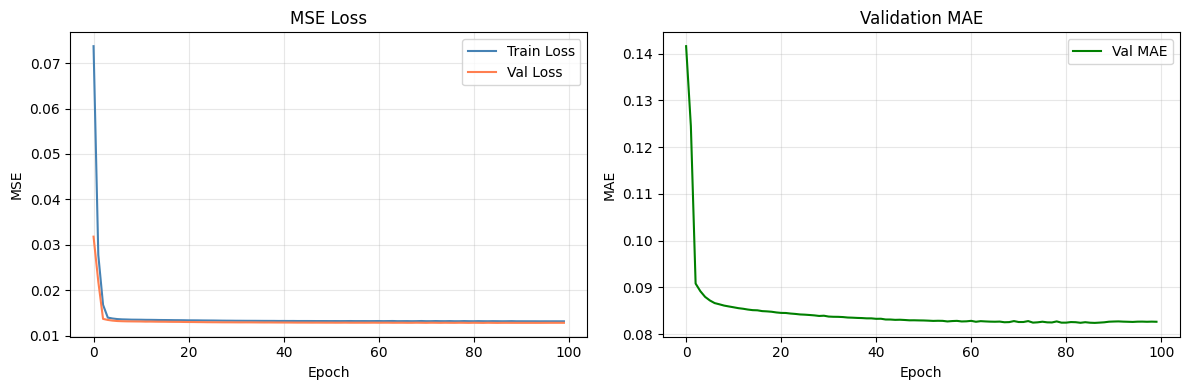

✅ Courbes sauvegardées


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='coral')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_mae'], label='Val MAE', color='green')
axes[1].set_title('Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('✅ Courbes sauvegardées')

## 11. Évaluation sur le Test Set

In [31]:
model.eval()
test_preds, test_true = [], []

with torch.no_grad():
    for i in range(n_test):
        x = X_test_t[i].unsqueeze(0).to(DEVICE)
        y = Y_test_t[i].to(DEVICE)
        pred = model(x, edge_index, edge_weight)
        test_preds.append(pred.cpu().numpy())
        test_true.append(y.cpu().numpy())

test_preds_flat = np.concatenate(test_preds)   # (n_test * N,)
test_true_flat  = np.concatenate(test_true)

# ── Métriques ────────────────────────────────────────────────────────────────
mse  = mean_squared_error(test_true_flat, test_preds_flat)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test_true_flat, test_preds_flat)
r2   = r2_score(test_true_flat, test_preds_flat)

print('=' * 50)
print('📊 RÉSULTATS TEST SET')
print('=' * 50)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  R²   : {r2:.4f}')
print('=' * 50)

# ── Sauvegarder les métriques ────────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2
}])
metrics_df.to_csv('test_metrics.csv', index=False)
print('✅ Métriques sauvegardées : test_metrics.csv')

📊 RÉSULTATS TEST SET
  MSE  : 0.0128
  RMSE : 0.1133
  MAE  : 0.0826
  R²   : 0.5081
✅ Métriques sauvegardées : test_metrics.csv


## 12. Visualisation Prédictions vs Réel

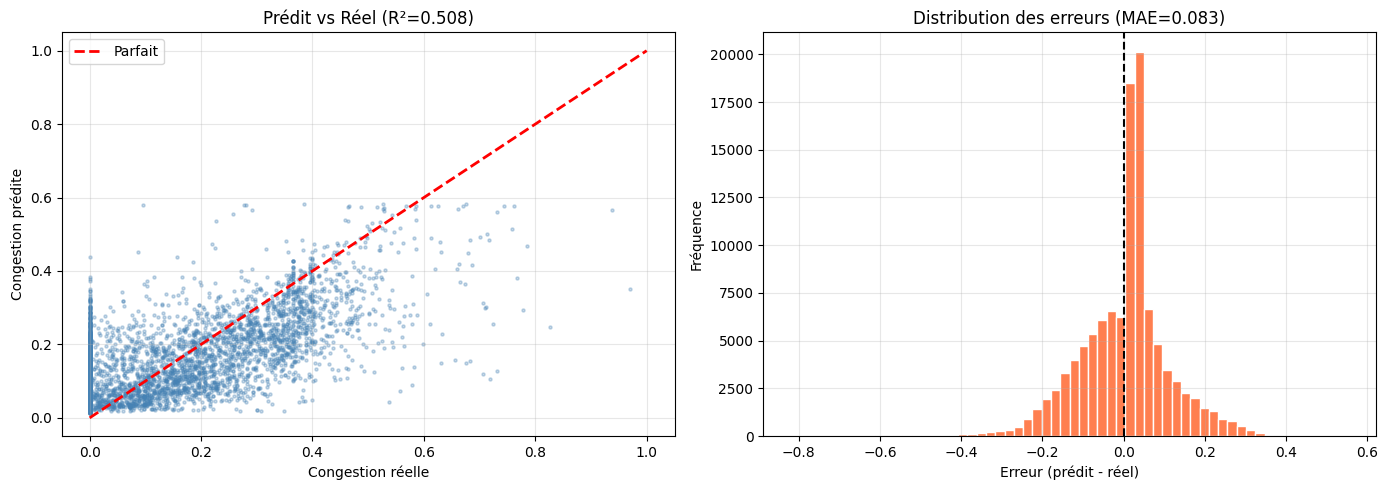

✅ Visualisation sauvegardée


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter plot : prédit vs réel ─────────────────────────────────────────────
sample_idx = np.random.choice(len(test_true_flat), size=5000, replace=False)
axes[0].scatter(test_true_flat[sample_idx], test_preds_flat[sample_idx],
                alpha=0.3, s=5, color='steelblue')
axes[0].plot([0,1],[0,1], 'r--', linewidth=2, label='Parfait')
axes[0].set_xlabel('Congestion réelle')
axes[0].set_ylabel('Congestion prédite')
axes[0].set_title(f'Prédit vs Réel (R²={r2:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Distribution des erreurs ──────────────────────────────────────────────────
errors = test_preds_flat - test_true_flat
axes[1].hist(errors, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Erreur (prédit - réel)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Distribution des erreurs (MAE={mae:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_vs_real.png', dpi=150)
plt.show()
print('✅ Visualisation sauvegardée')

## 13. Analyse par jour de la semaine

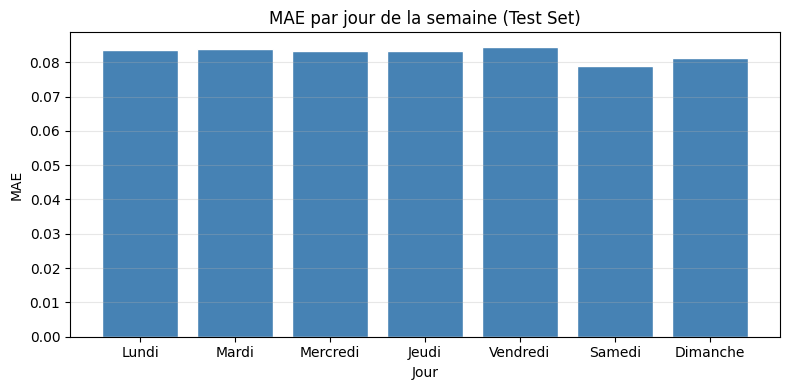

MAE par jour :
  Lundi        : 0.0836
  Mardi        : 0.0838
  Mercredi     : 0.0834
  Jeudi        : 0.0832
  Vendredi     : 0.0845
  Samedi       : 0.0789
  Dimanche     : 0.0813


In [33]:
# ── MAE par jour de la semaine sur le test set ────────────────────────────────
jours_noms = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
test_start_day = n_train + n_val + MAX_LAG

mae_par_jour = {j: [] for j in range(7)}

for i in range(n_test):
    day_abs = test_start_day + i
    dow = (start_date + datetime.timedelta(days=day_abs)).weekday()
    err = np.abs(test_preds[i] - test_true[i]).mean()
    mae_par_jour[dow].append(err)

mae_means = [np.mean(v) if v else 0 for v in mae_par_jour.values()]

plt.figure(figsize=(8,4))
plt.bar(jours_noms, mae_means, color='steelblue', edgecolor='white')
plt.title('MAE par jour de la semaine (Test Set)')
plt.ylabel('MAE')
plt.xlabel('Jour')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('mae_par_jour.png', dpi=150)
plt.show()

print('MAE par jour :')
for j, mae_j in zip(jours_noms, mae_means):
    print(f'  {j:12s} : {mae_j:.4f}')

## 14. Résumé final

In [34]:
print('=' * 60)
print('📋 RÉSUMÉ FINAL — Task B ST-GCN')
print('=' * 60)
print(f'Dataset        : METR-CA 2021 — {N_DAYS_USE} jours utilisés')
print(f'Capteurs       : {N_SENSORS:,}')
print(f'Arcs           : {edge_index.shape[1]:,}')
print(f'Features/nœud  : {F_TOTAL}')
print(f'Séquence input : J-1, J-2, J-7')
print(f'Split          : {n_train}/{n_val}/{n_test} jours (train/val/test)')
print(f'Paramètres     : {total_params:,}')
print('-' * 60)
print(f'MSE  = {mse:.4f}')
print(f'RMSE = {rmse:.4f}')
print(f'MAE  = {mae:.4f}')
print(f'R²   = {r2:.4f}')
print('=' * 60)
print('Fichiers générés :')
print('  stgcn_best.pt             → modèle sauvegardé')
print('  test_metrics.csv          → métriques test')
print('  training_curves.png       → courbes apprentissage')
print('  predictions_vs_real.png   → scatter prédit vs réel')
print('  mae_par_jour.png          → MAE par jour semaine')
print('  congestion_distribution.png → distribution congestion')

📋 RÉSUMÉ FINAL — Task B ST-GCN
Dataset        : METR-CA 2021 — 90 jours utilisés
Capteurs       : 8,600
Arcs           : 209,963
Features/nœud  : 4
Séquence input : J-1, J-2, J-7
Split          : 58/12/13 jours (train/val/test)
Paramètres     : 31,553
------------------------------------------------------------
MSE  = 0.0128
RMSE = 0.1133
MAE  = 0.0826
R²   = 0.5081
Fichiers générés :
  stgcn_best.pt             → modèle sauvegardé
  test_metrics.csv          → métriques test
  training_curves.png       → courbes apprentissage
  predictions_vs_real.png   → scatter prédit vs réel
  mae_par_jour.png          → MAE par jour semaine
  congestion_distribution.png → distribution congestion
